# Sinhala Document OCR — Local Pipeline (Windows + Jupyter)

End-to-end **baseline + fine-tune + inference** on your laptop (same goals as `notebooks/colab_pipeline.ipynb`, without Drive).

## Table of contents

| Step | Section | Est. time | Skip when |
|------|---------|-----------|-----------|
| 1 | Setup & fonts | ~30 s | — |
| 2 | Install deps (optional) | ~2 min | `RUN_PIP_INSTALL=False` |
| 3 | **Pipeline control** (flags) | instant | — |
| 4 | Generate synthetic data | ~5 min | `RUN_GENERATE=False` + train labels exist |
| 5 | Baseline CRNN train | 30–60 min GPU | `RUN_BASELINE_TRAIN=False` + `crnn_best.pth` |
| 6 | Evaluate baseline (synthetic test) | ~1 min | optional |
| 7 | Fine-tune on Kanyawee poem | 2–5 min GPU | `RUN_FINETUNE=False` + `crnn_finetuned.pth` |
| 8 | Poem before/after CER | ~30 s | needs poem crops |
| 9 | Test: digital upload / scan | ~1 min | `RUN_UPLOAD_TEST=False` |
| 10 | Test: real phone photo | ~1 min | `RUN_REAL_PHOTO=False` |
| 11 | Optional save debug (upload) | instant | — |

### Why two training stages?

You only train **twice** in the MSc sense:

1. **Baseline** on synthetic lines → general Sinhala CRNN (`models/crnn_best.pth`).
2. **Fine-tune** on ~10 real poem lines (repeated in the trainer) → document-specific weights (`models/crnn_finetuned.pth`).

That is **not** running the same job twice: baseline learns the charset; fine-tune adapts to your poem page and height **64**. After the first successful run, set `RUN_BASELINE_TRAIN=False` and `RUN_FINETUNE=False` and only re-run inference sections (9–10).

**First run:** set all `RUN_*` training flags to `True`. **Later testing:** only `RUN_UPLOAD_TEST` / `RUN_REAL_PHOTO` as needed.


## 1. Setup — project root and imports

The notebook lives in `notebooks/`; the repository root is the parent directory.


In [1]:
import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
if (NOTEBOOK_DIR / "local_pipeline.ipynb").exists():
    REPO_ROOT = NOTEBOOK_DIR.parent
elif (NOTEBOOK_DIR / "notebooks" / "local_pipeline.ipynb").exists():
    REPO_ROOT = NOTEBOOK_DIR
else:
    REPO_ROOT = NOTEBOOK_DIR.parent

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("cwd:", REPO_ROOT)
for name in ("src", "configs", "requirements.txt"):
    p = REPO_ROOT / name
    print(f"  {name}: {'OK' if p.exists() else 'MISSING'}", p)


cwd: C:\Users\ASUS TUF\Projects\sinhala-document-ocr
  src: OK C:\Users\ASUS TUF\Projects\sinhala-document-ocr\src
  configs: OK C:\Users\ASUS TUF\Projects\sinhala-document-ocr\configs
  requirements.txt: OK C:\Users\ASUS TUF\Projects\sinhala-document-ocr\requirements.txt


## 2. Install dependencies (optional)

Run once per Python environment. Set `RUN_PIP_INSTALL=True` below on a fresh venv.


In [2]:
RUN_PIP_INSTALL = False  # True once per new environment

if RUN_PIP_INSTALL:
    %pip install -q -r requirements.txt
else:
    print("Skipping pip install (set RUN_PIP_INSTALL=True on a new environment).")


Skipping pip install (set RUN_PIP_INSTALL=True on a new environment).


## 3. Font setup (Windows)

Synthetic lines use installed Sinhala fonts. Probed paths: **Nirmala UI** (`Nirmala.ttc`), **Iskoola Pota** (`iskpota.ttf`), and repo **Noto Sans Sinhala**.


In [3]:
from pathlib import Path

FONT_CANDIDATES = [
    Path(r"C:/Windows/Fonts/Nirmala.ttc"),
    Path(r"C:/Windows/Fonts/iskpota.ttf"),  # Iskoola Pota
    REPO_ROOT / "fonts" / "NotoSansSinhala-Regular.ttf",
]

FONT_PATHS = [str(p) for p in FONT_CANDIDATES if p.is_file()]
if not FONT_PATHS:
    print(
        "WARNING: No Sinhala font found. Install Nirmala UI / Iskoola Pota (iskpota.ttf) "
        "or place Noto Sans Sinhala under fonts/."
    )
else:
    print("Using fonts:")
    for fp in FONT_PATHS:
        label = "Iskoola Pota" if fp.lower().endswith("iskpota.ttf") else Path(fp).name
        print(f"  {label}: {fp}")


Using fonts:
  Nirmala.ttc: C:\Windows\Fonts\Nirmala.ttc


## 4. Pipeline control — main config

Edit flags here before re-running downstream cells.

**v2 (general model):** the baseline is trained on a **diverse real-text corpus**
(`src/data/corpus_sinhala.txt`, 3000+ distinct Sinhala lines) with varied fonts/sizes/layouts,
and detection defaults to the **projection-profile** method (robust to decorative borders,
watermarks and centered lines). A **full retrain is required** after this upgrade:
set `RUN_GENERATE=True` and `RUN_BASELINE_TRAIN=True` once (defaults below: 30000 samples,
40 epochs with early stopping on GPU).

**Poem fine-tuning (Section 8) is an OPTIONAL experiment** — the Kanyawee poem was a
test case, not the strategy. The baseline checkpoint (`crnn_best.pth`) is the model
for arbitrary Sinhala documents; `CHECKPOINT_MODE` defaults to `"baseline"`.

**v3 (domain-gap fix):** line-crop synthetic CER was misleadingly good (~4%) while real full-page photos still failed. Root cause: training only ever saw idealised single-line crops, never the imperfect crops the real `ProjectionLineDetector` produces from a whole page (mis-padding, border/watermark bleed, merged/split lines), and only ONE font family (Nirmala UI) was actually available on disk despite the multi-font code path. Fixes: more realistic per-line augmentation (paper texture, defocus blur, moire, edge/border-fragment artifacts, multi-pass JPEG), 4 extra Sinhala font families (`fonts/`, see `scripts/download_fonts.ps1`), and a new **detector-in-the-loop page generator** (`src/data/page_synth.py`, `scripts/generate_pages.py`) that renders full pages, runs the real detector, and trains on its *actual* output crops. Set `RUN_GENERATE_PAGES=True` below once. See `scripts/run_realistic_eval.py` / `scripts/build_adversarial_pages.py` for the full-pipeline (not just line-crop) evaluation that actually proves this worked.


In [4]:
from pathlib import Path

import subprocess
import sys

import torch
from src.utils.common import load_config, get_logger, resolve_recognition_checkpoint
from src.utils.display import configure_display_utf8, setup_matplotlib_sinhala
from src.recognition.inference import inference_options_from_config

configure_display_utf8()
logger = get_logger("local_pipeline")

# === PIPELINE CONTROL ===
RUN_GENERATE = False       # True: first time or refresh synthetic data
RUN_GENERATE_PAGES = False  # True: (re)generate the detector-in-the-loop page supplement (v3)
RESUME_FROM_PRE_V3_CKPT = True  # True: warm-start baseline training from the existing crnn_best.pth
RUN_BASELINE_TRAIN = False  # True: first time; ~25 epochs on GPU
RUN_FINETUNE = False        # OPTIONAL experiment (poem test case); keep False for the general model
RUN_UPLOAD_TEST = True      # Section 9 - digital scan / upload
RUN_REAL_PHOTO = True       # Section 10 - phone camera

NUM_SAMPLES = 30000 if torch.cuda.is_available() else 5000  # v2: diverse corpus needs volume
NUM_PAGES = 4000 if torch.cuda.is_available() else 300  # v3: detector-in-the-loop page supplement
BASELINE_EPOCHS = 40   # early stopping (patience 8 on val CER) usually ends sooner
FINETUNE_EPOCHS = 20

# Recognition checkpoint selection (general docs vs Kanyawee poem fine-tune)
# auto: crnn_best.pth for uploads unless COMPARE_TO_POEM_GT or USE_POEM_FINETUNE
CHECKPOINT_MODE = "baseline"  # "baseline" (general model, default) | "auto" | "finetuned" (poem experiment)
USE_POEM_FINETUNE = False  # True: force poem weights in auto mode (not for LaTeX/general docs)
INFERENCE_HEIGHT = 64      # overridden from finetune config when finetuned ckpt is selected
DECODE = "greedy"

# Fine-tune extras (Section 7)
FT_POEM_REPEAT = 50
FT_SYN_MAX = 3000
FT_USE_REAL_ONLY = False
FT_RUN_PREP = False  # True: run prepare_poem_dataset.py from POEM_IMAGE

# Upload / real-photo options (Sections 9-10)
DETECTION_METHOD = "projection"  # "projection" (default: borders/watermarks/centered lines) | "contours"

SECTION9_PICK_FILE = False
LOCAL_UPLOAD_PATH = ""
INVERT_IF_DARK_BG = True
SKIP_DOCUMENT_BINARIZE = True
USE_WHOLE_IMAGE_IF_ONE_LINE = True

TEST_MODE = "upload"  # "upload" | "file_path" for Section 10
REAL_PHOTO_PATH = ""
COMPARE_TO_POEM_GT = False  # True only for same Kanyawee poem page (10 lines)
POEM_GT_LABELS = "data/real/labels/poem_kanyawee.txt"
INVERT_IF_DARK_BG_C = True
SKIP_DOCUMENT_BINARIZE_C = True

CONFIG_PATH = str(REPO_ROOT / "configs" / "local.yaml")
cfg = load_config(CONFIG_PATH)

if FONT_PATHS:
    cfg["synthetic"]["fonts"] = FONT_PATHS

PRIMARY_FONT = FONT_PATHS[0] if FONT_PATHS else None
MPL_FONT = setup_matplotlib_sinhala(PRIMARY_FONT)
if MPL_FONT:
    print("Matplotlib Sinhala font:", MPL_FONT)

CUDA = torch.cuda.is_available()
DEVICE = "cuda" if CUDA else "cpu"
BATCH_SIZE = cfg["train"]["batch_size"]
if not CUDA and BATCH_SIZE > 16:
    BATCH_SIZE = 16

OUT_DIR = cfg["paths"]["synthetic_dir"]
PAGES_DIR = cfg["paths"].get("synthetic_pages_dir", "data/synthetic_pages")
PAGES_TRAIN_LABELS = REPO_ROOT / PAGES_DIR / "train_labels.txt"
UPLOADS_DIR = cfg["paths"].get("uploads_dir", "data/uploads")
DEBUG_DIR = cfg["paths"].get("debug_dir", "data/debug")
MODELS_DIR = REPO_ROOT / cfg["paths"]["models_dir"]
BASELINE_CKPT = MODELS_DIR / "crnn_best.pth"
FINETUNED_CKPT = MODELS_DIR / "crnn_finetuned.pth"
TRAIN_LABELS = REPO_ROOT / OUT_DIR / "train_labels.txt"
MIN_TRAIN_LINES = max(500, int(NUM_SAMPLES * cfg["synthetic"]["split"][0] * 0.5))

finetune_cfg_path = REPO_ROOT / "configs" / "finetune.yaml"

_upload_ckpt = resolve_recognition_checkpoint(
    cfg,
    REPO_ROOT,
    mode=CHECKPOINT_MODE,
    compare_to_poem_gt=False,
    use_poem_finetune=USE_POEM_FINETUNE,
)
_uses_finetune_weights = Path(_upload_ckpt).name == FINETUNED_CKPT.name and FINETUNED_CKPT.is_file()
_inf_src = load_config(str(finetune_cfg_path)) if (_uses_finetune_weights and finetune_cfg_path.is_file()) else cfg
INF_OPTS = inference_options_from_config(_inf_src)
INF_OPTS["decode"] = DECODE
if INFERENCE_HEIGHT:
    INF_OPTS["height"] = INFERENCE_HEIGHT

cfg["detection"]["method"] = DETECTION_METHOD

print("config:", CONFIG_PATH)
print("CHECKPOINT_MODE:", CHECKPOINT_MODE, "| USE_POEM_FINETUNE:", USE_POEM_FINETUNE)
print(
    "Default upload checkpoint:",
    Path(_upload_ckpt).name,
    "(set CHECKPOINT_MODE='baseline' for new LaTeX/general documents)",
)
print("CUDA:", CUDA, "| device:", DEVICE)
print("NUM_SAMPLES:", NUM_SAMPLES, "| BASELINE_EPOCHS:", BASELINE_EPOCHS, "| FINETUNE_EPOCHS:", FINETUNE_EPOCHS)
print("INF_OPTS height:", INF_OPTS["height"], "| decode:", INF_OPTS["decode"])
print("detection method:", DETECTION_METHOD)
print("synthetic:", OUT_DIR, "| uploads:", UPLOADS_DIR)


Matplotlib Sinhala font: C:\Windows\Fonts\Nirmala.ttc
config: C:\Users\ASUS TUF\Projects\sinhala-document-ocr\configs\local.yaml
CHECKPOINT_MODE: auto | USE_POEM_FINETUNE: False
Default upload checkpoint: crnn_best.pth (set CHECKPOINT_MODE='baseline' for new LaTeX/general documents)
CUDA: True | device: cuda
NUM_SAMPLES: 15000 | BASELINE_EPOCHS: 25 | FINETUNE_EPOCHS: 20
INF_OPTS height: 64 | decode: greedy
synthetic: data/synthetic | uploads: data/uploads


## 5. Generate synthetic data (optional)

Writes train/val/test splits under `data/synthetic/`. Skipped when `RUN_GENERATE=False` and enough labels already exist.

v2 lines are sampled mostly from the real-sentence corpus `src/data/corpus_sinhala.txt`
(plus word recombinations, numbers, dates), rendered with every available Sinhala font
face (all 6 Nirmala UI/Text faces on Windows), sizes 24-72, varied colours/backgrounds/padding.


In [5]:
from src.data.synthetic_generator import generate, load_corpus, load_word_lists

STEP = "5/11: Generate synthetic"
if not RUN_GENERATE and TRAIN_LABELS.is_file():
    n_lines = sum(1 for _ in TRAIN_LABELS.open(encoding="utf-8"))
    if n_lines >= MIN_TRAIN_LINES:
        print(f"Step {STEP} SKIPPED ({TRAIN_LABELS.name} has {n_lines} lines; RUN_GENERATE=False)")
    else:
        print(f"Step {STEP}: labels exist but only {n_lines} lines (< {MIN_TRAIN_LINES}); generating...")
        RUN_GENERATE = True
else:
    if not RUN_GENERATE:
        print(f"Step {STEP} SKIPPED (no labels; set RUN_GENERATE=True to create data)")
    else:
        print(f"Step {STEP}: generating {NUM_SAMPLES} samples...")

if RUN_GENERATE:
    words = load_word_lists([cfg["paths"]["word_list"], cfg["paths"].get("form_vocab")], warn=logger.warning)
    print("Vocabulary entries:", len(words))
    corpus = load_corpus(cfg["paths"].get("corpus"), warn=logger.warning)
    print("Corpus lines:", len(corpus))
    counts = generate(
        out_dir=OUT_DIR,
        num_samples=NUM_SAMPLES,
        font_paths=cfg["synthetic"]["fonts"],
        font_sizes=cfg["synthetic"]["font_sizes"],
        words=words,
        min_words=cfg["synthetic"]["min_words"],
        max_words=cfg["synthetic"]["max_words"],
        augment=cfg["synthetic"]["augment"],
        split=cfg["synthetic"]["split"],
        seed=cfg["project"]["seed"],
        logger=logger,
        numeric_ratio=cfg["synthetic"]["numeric_ratio"],
        mixed_ratio=cfg["synthetic"]["mixed_ratio"],
        corpus=corpus,
        corpus_ratio=float(cfg["synthetic"].get("corpus_ratio", 0.65)),
    )
    print("Split counts:", counts)


Step 5/11: Generate synthetic SKIPPED (train_labels.txt has 10500 lines; RUN_GENERATE=False)


## 5b. Generate detector-in-the-loop page supplement (optional, v3 domain-gap fix)

Renders full synthetic PAGES (paragraph / bordered card / poem / mixed Sinhala-English / letterhead), runs the *real* `ProjectionLineDetector` over each rendered page, and saves the detector's actual output crops paired with their transcript (`src/data/page_synth.py`). This is what closes the train/inference distribution gap - training only on idealised line crops (Section 5) taught the recognizer nothing about the imperfect crops a real detector produces from a real page.

Writes `data/synthetic_pages/{train,val}_labels.txt`; merged into training in Section 6 via `--extra-labels` whenever the file exists. Skipped when `RUN_GENERATE_PAGES=False` and the labels already exist.


In [ ]:
from src.data.page_synth import LAYOUTS, generate_detector_in_the_loop

STEP = "5b/11: Generate detector-in-the-loop pages"
if not RUN_GENERATE_PAGES and PAGES_TRAIN_LABELS.is_file():
    n_lines = sum(1 for _ in PAGES_TRAIN_LABELS.open(encoding="utf-8"))
    print(f"Step {STEP} SKIPPED ({PAGES_TRAIN_LABELS.name} has {n_lines} lines; RUN_GENERATE_PAGES=False)")
elif not RUN_GENERATE_PAGES:
    print(f"Step {STEP} SKIPPED (no page labels; set RUN_GENERATE_PAGES=True to create them)")
else:
    print(f"Step {STEP}: rendering {NUM_PAGES} pages + running the detector...")
    corpus = load_corpus(cfg["paths"].get("corpus"), warn=logger.warning)
    stats = generate_detector_in_the_loop(
        out_dir=PAGES_DIR,
        num_pages=NUM_PAGES,
        font_paths=cfg["synthetic"]["fonts"],
        font_sizes=cfg["synthetic"]["font_sizes"],
        corpus=corpus,
        detection_cfg=cfg.get("detection", {}),
        layouts=LAYOUTS,
        seed=cfg["project"]["seed"] + 1,
        logger=logger,
    )
    print("Page-supplement crops:", stats["num_crops"], "| per-layout detector match rate:", stats["match_rate"])


### Preview generated lines (optional)

Visual check only; training uses Unicode labels on disk.


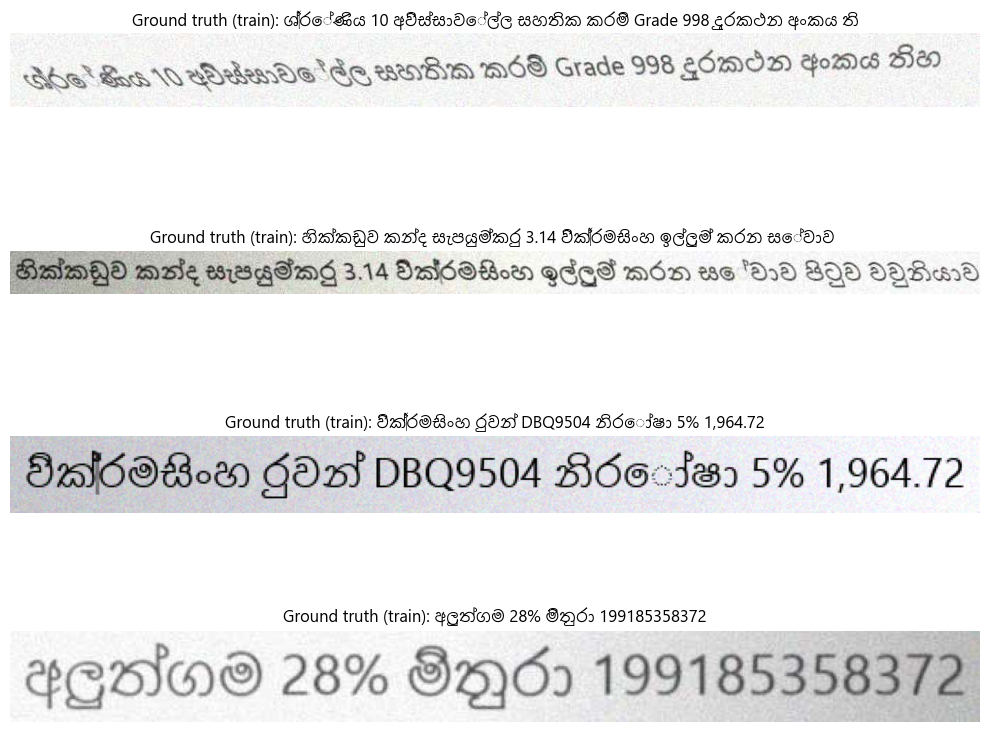

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
from src.data.dataset import read_labels

train_path = REPO_ROOT / OUT_DIR / "train_labels.txt"
if not train_path.is_file():
    print("No train_labels.txt — run Section 5 with RUN_GENERATE=True.")
else:
    rows = read_labels(str(train_path))
    n = min(4, len(rows))
    fig, axes = plt.subplots(n, 1, figsize=(10, 2.2 * n))
    if n == 1:
        axes = [axes]
    for ax, (rel, text) in zip(axes, rows[:n]):
        img = Image.open(REPO_ROOT / OUT_DIR / rel)
        ax.imshow(img, cmap="gray")
        ax.set_title(f"Ground truth (train): {text[:60]}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## 6. Baseline CRNN training (optional)

GPU default **40 epochs** with early stopping (patience 8 on val CER) and
ReduceLROnPlateau; batch **32**. Checkpoint: `models/crnn_best.pth`.
This is the ONE general model used for all documents.


In [7]:
STEP = "6/11: Baseline training"
if not RUN_BASELINE_TRAIN and BASELINE_CKPT.is_file():
    print(f"Step {STEP} SKIPPED — using existing checkpoint:", BASELINE_CKPT)
elif not RUN_BASELINE_TRAIN:
    print(f"Step {STEP} SKIPPED (RUN_BASELINE_TRAIN=False and no {BASELINE_CKPT.name})")
elif not TRAIN_LABELS.is_file():
    raise FileNotFoundError(f"Missing {TRAIN_LABELS}; run Section 5 with RUN_GENERATE=True")
else:
    print(f"Step {STEP}: {BASELINE_EPOCHS} epochs on {DEVICE}...")
    if DEVICE == "cpu":
        print("WARNING: CPU training is slow — reduce samples/epochs or use CUDA.")
    cmd = [
        sys.executable,
        "-m",
        "src.recognition.train",
        "--config",
        CONFIG_PATH,
        f"paths.synthetic_dir={OUT_DIR}",
        f"train.epochs={BASELINE_EPOCHS}",
        f"train.batch_size={BATCH_SIZE}",
        f"train.device={DEVICE}",
    ]
    # v3: merge the detector-in-the-loop page-crop supplement when it exists
    # (see Section 5b) - this is the actual domain-gap fix, not just more synthetic lines.
    if PAGES_TRAIN_LABELS.is_file():
        cmd += ["--extra-labels", str(PAGES_TRAIN_LABELS)]
        print("Merging page-supplement labels:", PAGES_TRAIN_LABELS)
    if RESUME_FROM_PRE_V3_CKPT and BASELINE_CKPT.is_file():
        cmd += ["--resume", str(BASELINE_CKPT)]
        print("Resuming weights from:", BASELINE_CKPT)
    print(" ".join(cmd))
    result = subprocess.run(cmd, cwd=str(REPO_ROOT))
    if result.returncode != 0:
        raise SystemExit(result.returncode)


Step 6/11: Baseline training SKIPPED — using existing checkpoint: C:\Users\ASUS TUF\Projects\sinhala-document-ocr\models\crnn_best.pth


## 7. Evaluate baseline on synthetic test set

CER / WER on `data/synthetic/test_labels.txt` using `crnn_best.pth`.


In [8]:
from src.charset import Charset
from src.data.dataset import build_dataloader, read_labels
from src.recognition.model import build_crnn
from src.evaluation.metrics import evaluate_model
from src.utils.common import load_checkpoint, get_device

if not BASELINE_CKPT.is_file():
    raise FileNotFoundError(f"Missing {BASELINE_CKPT}; train baseline or copy a checkpoint.")

charset = Charset.load(str(REPO_ROOT / cfg["paths"]["charset_path"]))
device = get_device(DEVICE)
model = build_crnn(charset.num_classes, cfg.get("model"), in_channels=cfg["image"]["channels"]).to(device)
load_checkpoint(str(BASELINE_CKPT), model, map_location=str(device))
model.eval()

test_loader = build_dataloader(
    str(REPO_ROOT / OUT_DIR / "test_labels.txt"),
    charset,
    batch_size=BATCH_SIZE,
    height=cfg["image"]["height"],
    max_width=cfg["image"]["max_width"],
    channels=cfg["image"]["channels"],
    shuffle=False,
    num_workers=cfg["train"]["num_workers"],
)

report = evaluate_model(model, test_loader, charset, device=device, measure_cpu_time=False)
print(f"TEST  samples={report['num_samples']}  CER={report['cer']:.4f}  WER={report['wer']:.4f}")


TEST  samples=2250  CER=0.0993  WER=0.2604


### Qualitative test predictions (baseline)


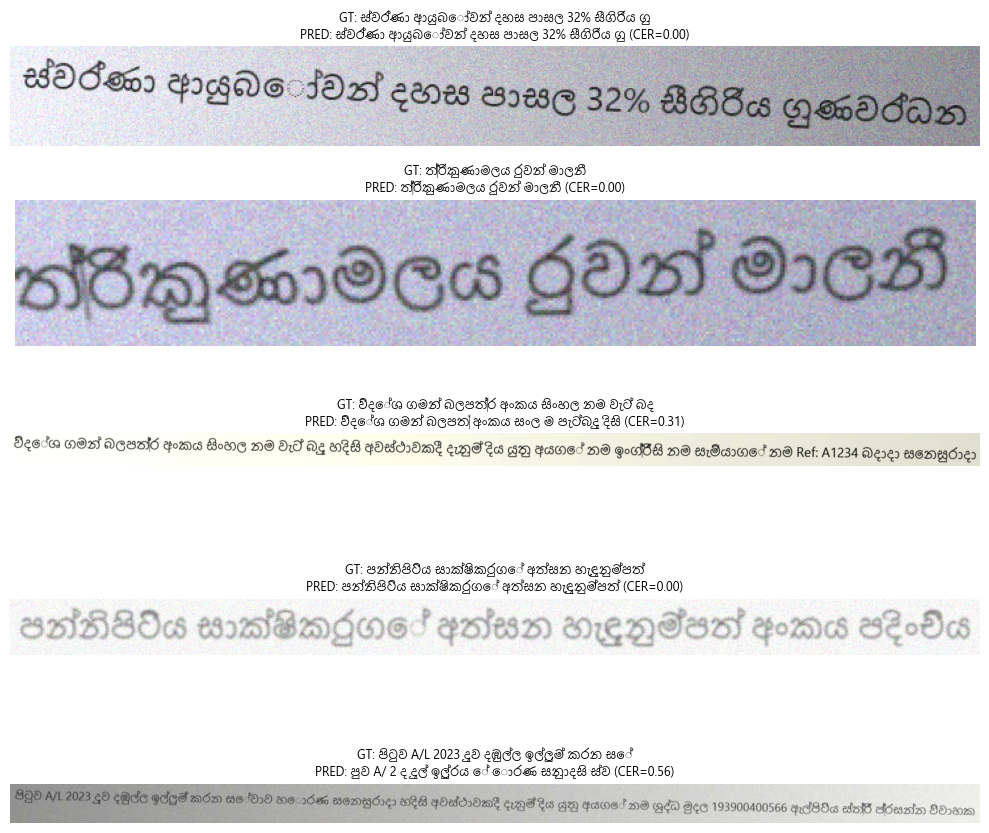

In [9]:
import matplotlib.pyplot as plt
from PIL import Image

test_rows = read_labels(str(REPO_ROOT / OUT_DIR / "test_labels.txt"))
n = min(5, len(test_rows))
fig, axes = plt.subplots(n, 1, figsize=(10, 1.8 * n))
if n == 1:
    axes = [axes]
for ax, (rel, _), sample in zip(axes, test_rows[:n], report["per_sample"][:n]):
    ax.imshow(Image.open(REPO_ROOT / OUT_DIR / rel), cmap="gray")
    ax.set_title(
        f"GT: {sample['ref'][:40]}\nPRED: {sample['hyp'][:40]} (CER={sample['cer']:.2f})",
        fontsize=9,
    )
    ax.axis("off")
plt.tight_layout()
plt.show()


## 8. OPTIONAL EXPERIMENT — fine-tune on real poem (Kanyawee)

> **This section is an optional experiment, not part of the main pipeline.** The poem
> fine-tune was a test case for adapting to a single known document. The general model
> is the baseline `crnn_best.pth`; per-document fine-tuning does NOT generalize and the
> resulting `crnn_finetuned.pth` usually produces garbage on other documents.
> Keep `RUN_FINETUNE=False` and `CHECKPOINT_MODE="baseline"` unless you are reproducing
> the poem experiment.

Ground truth: `data/real/labels/poem_kanyawee.txt`. Fine-tune saves `models/crnn_finetuned.pth` (inference height 64).


In [10]:
POEM_LABELS = REPO_ROOT / "data" / "real" / "labels" / "poem_kanyawee.txt"
STEP = "7/11: Fine-tune on poem"

if not POEM_LABELS.is_file():
    raise FileNotFoundError(POEM_LABELS)
print("Poem labels:", POEM_LABELS, "(", len(POEM_LABELS.read_text(encoding="utf-8").strip().splitlines()), "lines)")

if FT_RUN_PREP:
    POEM_IMAGE = str(REPO_ROOT / "data" / "uploads" / "test2.png")
    if not Path(POEM_IMAGE).is_file() and globals().get("UPLOADED_IMAGE_PATH"):
        POEM_IMAGE = UPLOADED_IMAGE_PATH
    prep_cmd = [sys.executable, "scripts/prepare_poem_dataset.py", "--image", POEM_IMAGE]
    print(" ".join(prep_cmd))
    subprocess.run(prep_cmd, cwd=str(REPO_ROOT), check=True)
else:
    print("Skipping prepare_poem_dataset.py — using existing labels/crops.")

if not RUN_FINETUNE and FINETUNED_CKPT.is_file():
    print(f"Step {STEP} SKIPPED — using {FINETUNED_CKPT.name} (RUN_FINETUNE=False)")
elif not RUN_FINETUNE:
    print(f"Step {STEP} SKIPPED (RUN_FINETUNE=False and no finetuned checkpoint)")
elif not BASELINE_CKPT.is_file():
    raise FileNotFoundError(f"Need baseline {BASELINE_CKPT} before fine-tuning")
else:
    print(f"Step {STEP}: {FINETUNE_EPOCHS} epochs...")
    finetune_cmd = [
        sys.executable,
        "-m",
        "src.recognition.train",
        "--config",
        str(finetune_cfg_path),
        "--resume",
        str(BASELINE_CKPT),
        "--extra-labels",
        str(POEM_LABELS),
        f"train.epochs={FINETUNE_EPOCHS}",
        f"train.extra_label_repeat={FT_POEM_REPEAT}",
        f"train.synthetic_train_max={FT_SYN_MAX}",
        "inference.image_height=64",
        f"train.device={DEVICE}",
    ]
    if FT_USE_REAL_ONLY:
        finetune_cmd.append("--finetune-real-only")
    print(" ".join(finetune_cmd))
    subprocess.run(finetune_cmd, cwd=str(REPO_ROOT), check=True)
    print("Finetuned checkpoint:", FINETUNED_CKPT)


Poem labels: C:\Users\ASUS TUF\Projects\sinhala-document-ocr\data\real\labels\poem_kanyawee.txt ( 10 lines)
Skipping prepare_poem_dataset.py — using existing labels/crops.
Step 7/11: Fine-tune on poem SKIPPED — using crnn_finetuned.pth (RUN_FINETUNE=False)


## 9. Poem before/after CER (Kanyawee)

Compares **baseline** vs **finetuned** on line crops in `data/real/` (from `poem_kanyawee.txt`). Run Section 8 first if you need fresh crops.


In [11]:
import cv2
from src.charset import Charset
import torch
from src.data.dataset import read_labels
from src.evaluation.metrics import cer, corpus_cer
from src.recognition.model import build_crnn
from src.recognition.predict import predict_line_array
from src.utils.common import load_checkpoint, get_device

POEM_LABELS = REPO_ROOT / "data" / "real" / "labels" / "poem_kanyawee.txt"
REAL_ROOT = REPO_ROOT / "data" / "real"
CHARSET_PATH = REPO_ROOT / cfg["paths"]["charset_path"]

if not POEM_LABELS.is_file():
    print("Step 8/11: Poem CER skipped — missing poem labels.")
else:
    poem_rows = read_labels(str(POEM_LABELS))
    line_crops_poem = []
    POEM_GT = []
    for rel, text in poem_rows:
        img_path = REAL_ROOT / rel
        if not img_path.is_file():
            img_path = REPO_ROOT / rel
        gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if gray is None:
            print("WARNING: missing crop", img_path)
            continue
        line_crops_poem.append(gray)
        POEM_GT.append(text)

    device = get_device(DEVICE)
    charset = Charset.load(str(CHARSET_PATH))
    auto_inv = INVERT_IF_DARK_BG and INF_OPTS["auto_invert"]

    def run_poem_ocr(checkpoint_name: str):
        ckpt = MODELS_DIR / checkpoint_name
        if not ckpt.is_file():
            return None
        m = build_crnn(charset.num_classes, cfg.get("model"), in_channels=INF_OPTS["channels"]).to(device)
        load_checkpoint(str(ckpt), m, map_location=str(device))
        m.eval()
        preds = []
        with torch.no_grad():
            for crop in line_crops_poem:
                preds.append(
                    predict_line_array(
                        m,
                        charset,
                        crop,
                        INF_OPTS["height"],
                        INF_OPTS["max_width"],
                        INF_OPTS["channels"],
                        device,
                        auto_invert=auto_inv,
                        denoise=INF_OPTS["denoise"],
                        min_model_width=INF_OPTS.get("min_model_width", 0),
                        pad_to_height=INF_OPTS.get("pad_to_height", True),
                        decode_mode=INF_OPTS.get("decode", "greedy"),
                        beam_width=int(INF_OPTS.get("beam_width", 10)),
                    )
                )
        return preds

    if POEM_GT and line_crops_poem:
        n = min(len(POEM_GT), len(line_crops_poem))
        before = run_poem_ocr("crnn_best.pth") or [""] * n
        after = run_poem_ocr("crnn_finetuned.pth") if FINETUNED_CKPT.is_file() else [""] * n
        rows = []
        cer_sum_b = cer_sum_a = 0.0
        for i in range(n):
            ref = POEM_GT[i]
            pb = before[i] if i < len(before) else ""
            pa = after[i] if i < len(after) else ""
            cb, ca = cer(ref, pb), cer(ref, pa)
            cer_sum_b += cb
            cer_sum_a += ca
            rows.append({
                "line": i + 1,
                "cer_before": round(cb, 4),
                "cer_after": round(ca, 4),
                "gt": ref,
                "pred_after": pa,
            })
        print(f"Step 8/11: Mean CER before {cer_sum_b / n:.4f} | after finetune {cer_sum_a / n:.4f}")
        print(f"Corpus CER after finetune: {corpus_cer(POEM_GT[:n], after[:n]):.4f}")
        try:
            import pandas as pd
            display(pd.DataFrame(rows)[["line", "cer_before", "cer_after", "pred_after"]])
        except ImportError:
            for r in rows:
                print(r)
    else:
        print("Step 8/11: no poem crops — set FT_RUN_PREP=True in Section 4 or run prepare_poem_dataset.py")


Step 8/11: Mean CER before 0.2712 | after finetune 0.1491
Corpus CER after finetune: 0.1543
{'line': 1, 'cer_before': 0.3158, 'cer_after': 0.0, 'gt': 'Kanyawee - කන්\u200dයාවී', 'pred_after': 'Kanyawee - කන්\u200dයාවී'}
{'line': 2, 'cer_before': 0.1944, 'cer_after': 0.0278, 'gt': 'මිනිසා මරණ තුනක් ඇති මිනිසා බලා සිටී', 'pred_after': 'මීනිසා මරණ තුනක් ඇති මිනිසා බලා සිටී'}
{'line': 3, 'cer_before': 0.2069, 'cer_after': 0.1379, 'gt': 'නිරුවත් දෑසින් බලන්න කන්\u200dයාවී', 'pred_after': 'නිරුවත් දසින් බලන්න කනාාවී'}
{'line': 4, 'cer_before': 0.3333, 'cer_after': 0.2222, 'gt': 'ලිහිල් සළුව අනතුරේ වැටෙද්දී', 'pred_after': 'ලිහිල් සටව අනතුමර් වෙටද්දී'}
{'line': 5, 'cer_before': 0.4286, 'cer_after': 0.4286, 'gt': 'පයෝධර තුඩු ඉකිබිඳිද්දී සංත්\u200dරාසයෙන්', 'pred_after': 'පෙශ්බර තුවු ඉණි බිදිද්දි සයතුාසෙයන්'}
{'line': 6, 'cer_before': 0.46, 'cer_after': 0.28, 'gt': 'අසංවාදී සුසුම් වේගේ රිද්\u200dමයෙන් වයන්න වීණා කන්\u200dයාවී', 'pred_after': 'අසංවාදී සුසුම් ඉවේග් රිද්මෙයන් වයන්න වීණා'}
{'line':

## 10. Test — digital upload / scan

Flatbed scans or clean digital exports. Set `LOCAL_UPLOAD_PATH` or drop a file in `data/uploads/`. For phone photos use **Section 11**.

Detection uses `DETECTION_METHOD` from Section 4 (`"projection"` default; `"contours"` is the legacy morphology fallback).


In [12]:
from tkinter import Tk, filedialog

upload_predictions = []
UPLOADED_IMAGE_PATH = ""
line_crops = []

if not RUN_UPLOAD_TEST:
    print("Step 9/11: Upload test SKIPPED (RUN_UPLOAD_TEST=False)")
else:
    upload_root = REPO_ROOT / UPLOADS_DIR
    upload_root.mkdir(parents=True, exist_ok=True)

    UPLOADED_IMAGE_PATH = LOCAL_UPLOAD_PATH.strip()
    if SECTION9_PICK_FILE:
        _root = Tk()
        _root.withdraw()
        _root.attributes("-topmost", True)
        picked = filedialog.askopenfilename(
            title="Select document image",
            filetypes=[("Images", "*.png;*.jpg;*.jpeg;*.bmp;*.tif;*.tiff"), ("All", "*.*")],
        )
        _root.destroy()
        if picked:
            UPLOADED_IMAGE_PATH = picked

    if not UPLOADED_IMAGE_PATH:
        for ext in ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff"):
            hits = sorted(upload_root.glob(ext))
            if hits:
                UPLOADED_IMAGE_PATH = str(hits[-1])
                break

    if not UPLOADED_IMAGE_PATH or not Path(UPLOADED_IMAGE_PATH).is_file():
        print(
            "Step 9/11: configure LOCAL_UPLOAD_PATH, SECTION9_PICK_FILE, or add an image to",
            upload_root,
        )
    else:
        print("Step 9/11: Using", UPLOADED_IMAGE_PATH)


Step 9/11: Using C:\Users\ASUS TUF\Projects\sinhala-document-ocr\data\uploads\test2.png


Loaded checkpoint: crnn_best.pth | mode=auto | height=64


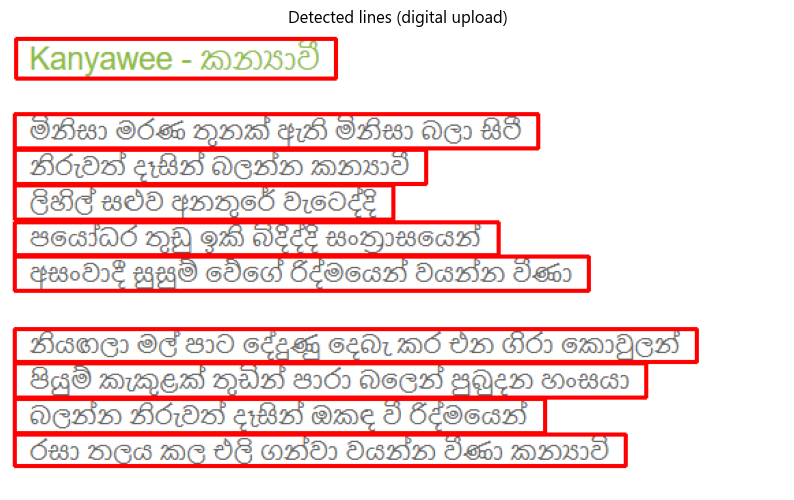

Line 1: KEyawee - කනලාචී
Line 2: මීනියා මරණ තුනක් අති මිනියා බලා සීිලි
Line 3: නිරාවත් දසින් බලන්න කනලාවිී
Line 4: ලිසිල් සටව අනතුමර වෙවද්ද
Line 5: පෙශ්බර තුවු ඉණි බිදිද්දි සයතුාසෙයන්
Line 6: අයයවාදි සුඳුම ඉවියශ් රද්මෙයන් වයන්න වීණා
Line 7: නියංඟලා මල් පාට ඉද්දණු දධා කර එන ගිරා මකාවුලන්
Line 8: පියුම කැකුළක් තුගින් පාරා බෙලන් පුමුදන හාසයා
Line 9: බලන්න නිරවත් දසින් මකද ව උද්මුයන්
Line 10: රසා තලය කල එලි ගන්වා වයන්න මීණා කනගාවී
--- Full transcription ---
KEyawee - කනලාචී
මීනියා මරණ තුනක් අති මිනියා බලා සීිලි
නිරාවත් දසින් බලන්න කනලාවිී
ලිසිල් සටව අනතුමර වෙවද්ද
පෙශ්බර තුවු ඉණි බිදිද්දි සයතුාසෙයන්
අයයවාදි සුඳුම ඉවියශ් රද්මෙයන් වයන්න වීණා
නියංඟලා මල් පාට ඉද්දණු දධා කර එන ගිරා මකාවුලන්
පියුම කැකුළක් තුගින් පාරා බෙලන් පුමුදන හාසයා
බලන්න නිරවත් දසින් මකද ව උද්මුයන්
රසා තලය කල එලි ගන්වා වයන්න මීණා කනගාවී


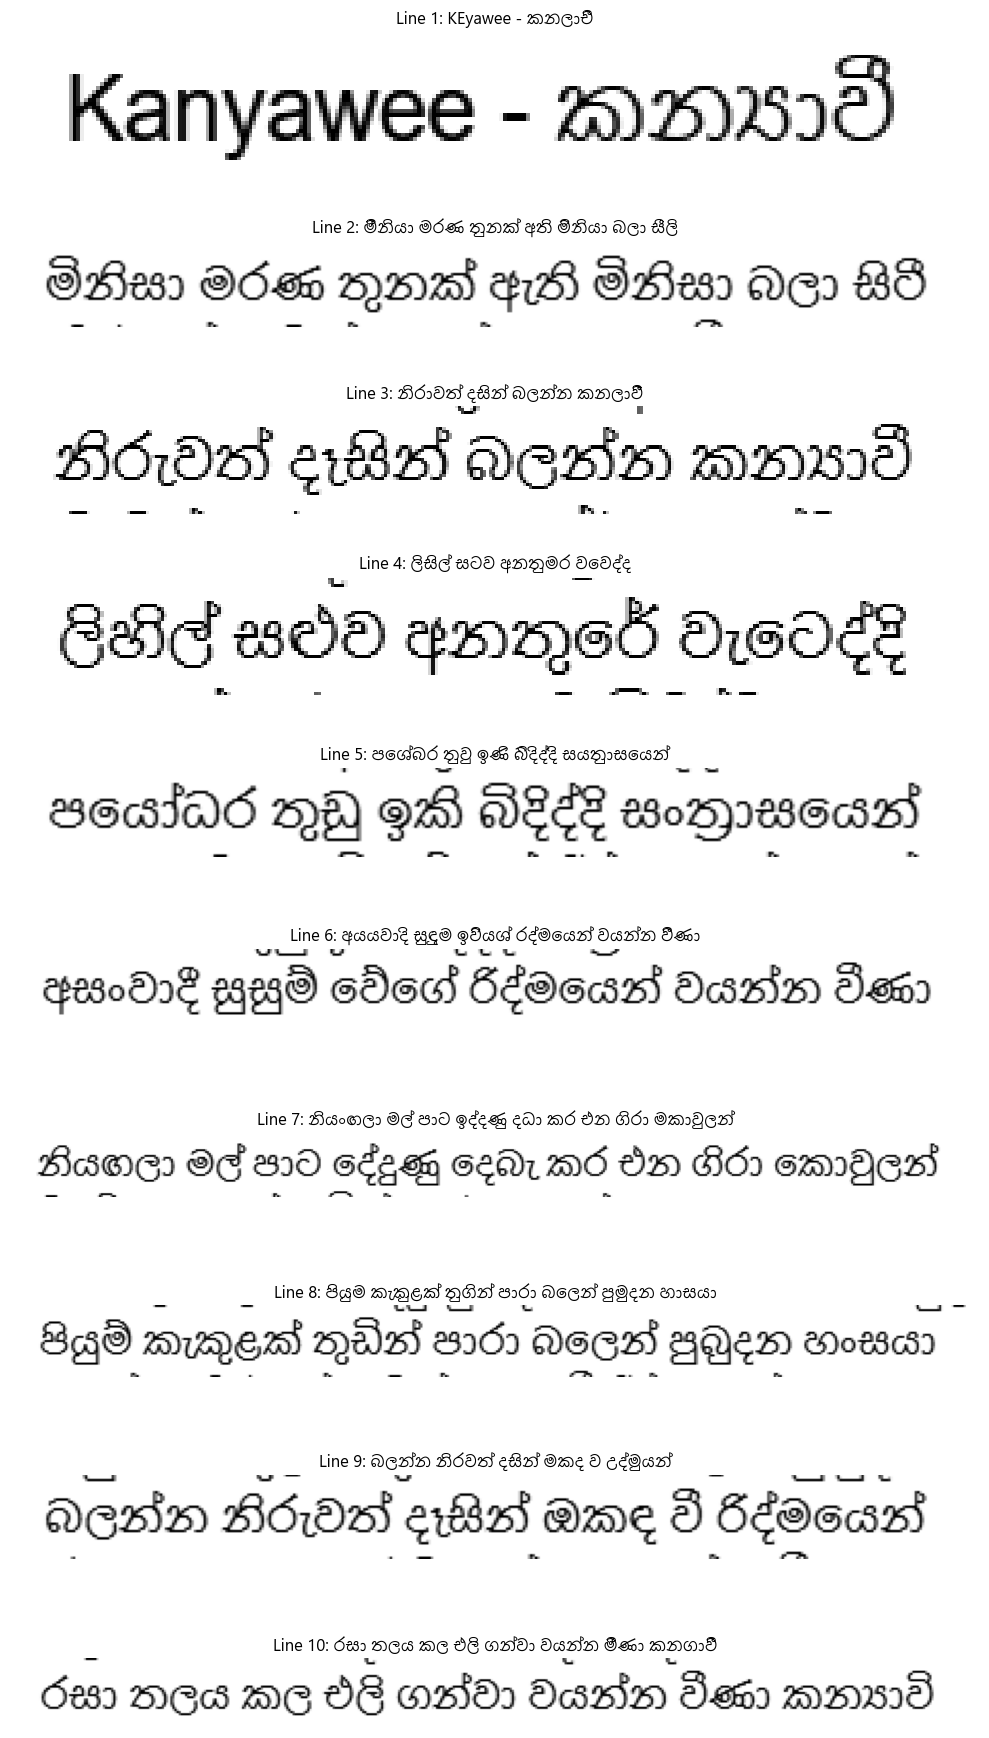

In [13]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import torch

from src.charset import Charset
from src.detection.text_detection import (
    build_detector,
    crop_is_mostly_numeric,
    crop_lines,
    draw_boxes,
    refine_document_boxes,
)
from src.preprocessing.preprocess import preprocess_document
from src.recognition.model import build_crnn
from src.recognition.predict import predict_line_array
from src.utils.common import get_device, load_checkpoint, resolve_recognition_checkpoint

if not RUN_UPLOAD_TEST:
    print("Upload OCR pipeline skipped.")
elif not UPLOADED_IMAGE_PATH or not Path(UPLOADED_IMAGE_PATH).is_file():
    raise RuntimeError("Configure an upload path in the cell above.")
else:
    CHECKPOINT_PATH = Path(
        resolve_recognition_checkpoint(
            cfg,
            REPO_ROOT,
            mode=CHECKPOINT_MODE,
            compare_to_poem_gt=False,
            use_poem_finetune=USE_POEM_FINETUNE,
        )
    )
    UPLOAD_CHECKPOINT_NAME = CHECKPOINT_PATH.name
    print(
        "Loaded checkpoint:",
        CHECKPOINT_PATH.name,
        f"| mode={CHECKPOINT_MODE} | height={INF_OPTS['height']}",
    )

    device = get_device(DEVICE)
    charset = Charset.load(str(REPO_ROOT / cfg["paths"]["charset_path"]))
    model = build_crnn(charset.num_classes, cfg.get("model"), in_channels=INF_OPTS["channels"]).to(device)
    load_checkpoint(str(CHECKPOINT_PATH), model, map_location=str(device))
    model.eval()

    page_bgr = cv2.imread(UPLOADED_IMAGE_PATH, cv2.IMREAD_COLOR)
    page_gray = cv2.cvtColor(page_bgr, cv2.COLOR_BGR2GRAY)
    page_for_det = page_gray if SKIP_DOCUMENT_BINARIZE else preprocess_document(page_bgr)

    skip_detection = False
    if USE_WHOLE_IMAGE_IF_ONE_LINE:
        ph, pw = page_gray.shape[:2]
        if pw >= 4 * ph or ph <= 3 * max(int(cfg["detection"]["min_line_height"]), 1):
            skip_detection = True
            print("[info] Single-line heuristic: using full image.")

    if skip_detection:
        boxes = [(0, 0, page_gray.shape[1], page_gray.shape[0])]
    else:
        detector = build_detector(cfg["detection"])  # DETECTION_METHOD from Section 4
        print("Detection method:", cfg["detection"].get("method", "projection"))
        boxes = detector.detect(page_for_det) or [(0, 0, page_for_det.shape[1], page_for_det.shape[0])]
        boxes = refine_document_boxes(
            boxes,
            min_line_height=int(cfg["detection"]["min_line_height"]),
            min_line_width=int(cfg["detection"]["min_line_width"]),
        )

    line_crops = crop_lines(
        page_gray,
        boxes,
        padding_x=int(cfg["detection"].get("crop_padding_x", 10)),
        padding_y=int(cfg["detection"].get("crop_padding_y", 5)),
        min_crop_height=int(cfg["detection"].get("min_crop_height", 14)),
    )

    page_with_boxes = draw_boxes(page_bgr, boxes)
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(page_with_boxes, cv2.COLOR_BGR2RGB))
    plt.title("Detected lines (digital upload)")
    plt.axis("off")
    plt.show()

    upload_predictions = []
    auto_inv = INVERT_IF_DARK_BG and INF_OPTS["auto_invert"]
    with torch.no_grad():
        for i, crop in enumerate(line_crops):
            if crop_is_mostly_numeric(crop):
                text = "[skipped: mostly numeric line]"
                print(f"Line {i + 1}: {text}")
                upload_predictions.append({"line": i + 1, "text": text, "crop": crop.copy()})
                continue
            text = predict_line_array(
                model,
                charset,
                crop,
                INF_OPTS["height"],
                INF_OPTS["max_width"],
                INF_OPTS["channels"],
                device,
                auto_invert=auto_inv,
                denoise=INF_OPTS["denoise"],
                min_model_width=INF_OPTS.get("min_model_width", 0),
                pad_to_height=INF_OPTS.get("pad_to_height", True),
                decode_mode=INF_OPTS.get("decode", "greedy"),
                beam_width=int(INF_OPTS.get("beam_width", 10)),
                warn_garbage=True,
            )
            upload_predictions.append({"line": i + 1, "text": text, "crop": crop.copy()})
            print(f"Line {i + 1}:", text)

    print("--- Full transcription ---")
    print("\n".join(p["text"] for p in upload_predictions))

    n_up = len(upload_predictions)
    if n_up:
        fig, axes = plt.subplots(n_up, 1, figsize=(10, 1.8 * n_up))
        if n_up == 1:
            axes = [axes]
        for ax, row in zip(axes, upload_predictions):
            ax.imshow(row["crop"], cmap="gray")
            ax.set_title(f"Line {row['line']}: {row['text'][:80]}")
            ax.axis("off")
        plt.tight_layout()
        plt.show()


## 11. Test - real captured photo

Phone camera photos (shadows, perspective). Uses `INF_OPTS` from Section 4 and `CHECKPOINT_MODE` (`auto` picks poem fine-tune only when `COMPARE_TO_POEM_GT=True` or `USE_POEM_FINETUNE=True`). For general documents set `CHECKPOINT_MODE="baseline"`.

Detection uses `DETECTION_METHOD` from Section 4 (`"projection"` default; `"contours"` fallback).


In [14]:
import shutil
from datetime import datetime, timezone
from tkinter import Tk, filedialog

real_photo_path = ""
real_capture_predictions = []

if not RUN_REAL_PHOTO:
    print("Step 10/11: Real photo test SKIPPED (RUN_REAL_PHOTO=False)")
else:
    upload_root = REPO_ROOT / UPLOADS_DIR
    upload_root.mkdir(parents=True, exist_ok=True)

    real_photo_path = REAL_PHOTO_PATH.strip()
    if TEST_MODE == "upload":
        _root = Tk()
        _root.withdraw()
        _root.attributes("-topmost", True)
        picked = filedialog.askopenfilename(
            title="Select real captured photo",
            filetypes=[("Images", "*.png;*.jpg;*.jpeg;*.bmp;*.tif;*.tiff"), ("All", "*.*")],
        )
        _root.destroy()
        if not picked:
            raise RuntimeError("No file selected.")
        stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
        dest = upload_root / f"real_capture_{stamp}{Path(picked).suffix.lower() or '.jpg'}"
        shutil.copy2(picked, dest)
        real_photo_path = str(dest)
        print("Copied to", dest)
    elif TEST_MODE == "file_path":
        if not real_photo_path:
            raise RuntimeError("Set REAL_PHOTO_PATH for file_path mode.")
        p = Path(real_photo_path)
        if not p.is_absolute():
            p = REPO_ROOT / p
        if not p.is_file():
            raise FileNotFoundError(p)
        real_photo_path = str(p)
    else:
        raise ValueError(f"Unknown TEST_MODE: {TEST_MODE}")

    print("Step 10/11: Real photo:", real_photo_path)


Copied to C:\Users\ASUS TUF\Projects\sinhala-document-ocr\data\uploads\real_capture_20260706T054800Z.jpg
Step 10/11: Real photo: C:\Users\ASUS TUF\Projects\sinhala-document-ocr\data\uploads\real_capture_20260706T054800Z.jpg


Loaded checkpoint: crnn_best.pth | mode=auto | compare_poem_gt=False | height=64


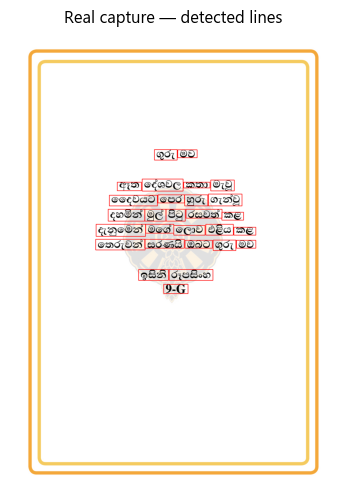

Line 1: ත් 7
Line 2:  ණු
Line 3: කු ුණු දල
Line 4: පු්
Line 5: දුද දණ
Line 6: ණණ්0
Line 7: 2ත්තු්
Line 8: ල සනත්
Line 9: සු්2
Line 10: ල ක ු ණුදලු ක්
Line 11: ණණුිතල්
Line 12: [skipped: mostly numeric line]
Line 13: [skipped: mostly numeric line]
Line 14: ර්සලණ්
Line 15: ණී ණලු
Line 16: ළුු තුතු තල්
Line 17: න න්
Line 18: ස ණලුණනු
Line 19: ත ලගණ
Line 20: ණී ණලු
Line 21:  ණත්7 ණුක්
Line 22: ණළිර් ණත් ණ්
Line 23: ත් 7
Line 24: ණු ත
Line 25:  ණු
Line 26: මු ණුතල
Line 27: ජ් සණුයඅ
Line 28: මණ්


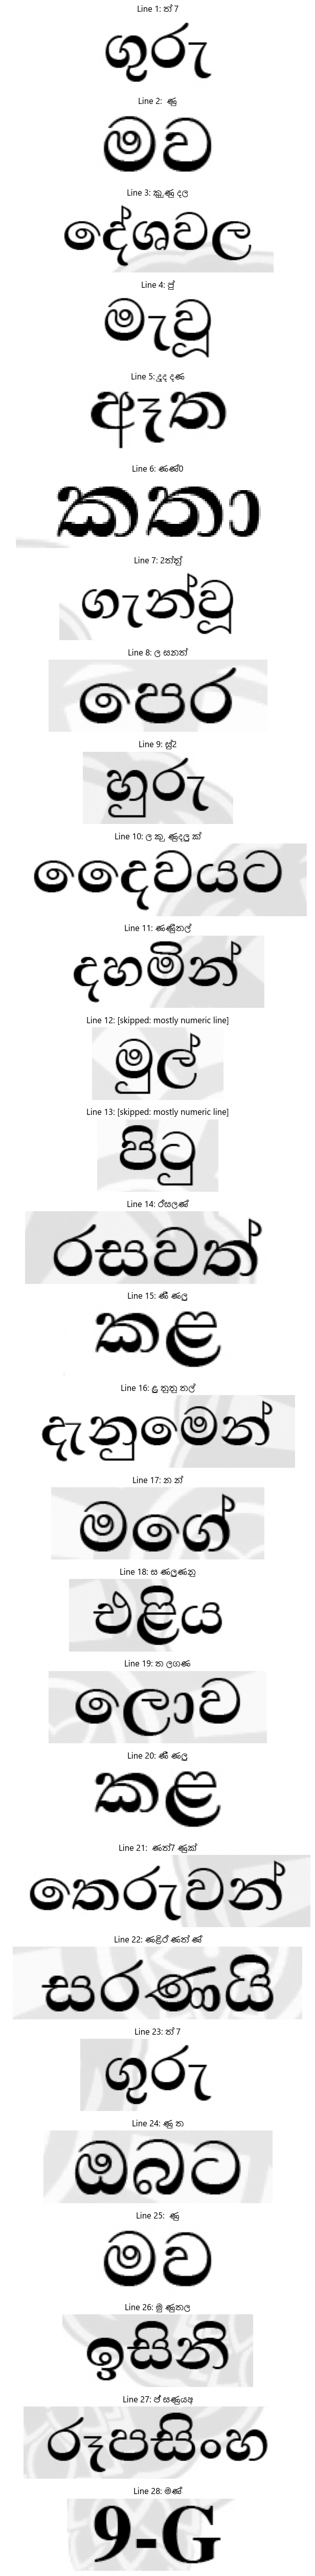

Saved debug outputs to C:\Users\ASUS TUF\Projects\sinhala-document-ocr\data\debug\real_capture_20260706T054803Z


In [15]:
from pathlib import Path
import json
import cv2
import matplotlib.pyplot as plt
import torch

from src.charset import Charset
from src.data.dataset import read_labels
from src.detection.text_detection import (
    build_detector,
    crop_is_mostly_numeric,
    crop_lines,
    draw_boxes,
    refine_document_boxes,
)
from src.evaluation.metrics import cer, corpus_cer
from src.preprocessing.preprocess import preprocess_document
from src.recognition.model import build_crnn
from src.recognition.predict import predict_line_array
from src.utils.common import get_device, load_checkpoint, resolve_recognition_checkpoint

if not RUN_REAL_PHOTO:
    print("Real capture pipeline skipped.")
else:
    ckpt_path = Path(
        resolve_recognition_checkpoint(
            cfg,
            REPO_ROOT,
            mode=CHECKPOINT_MODE,
            compare_to_poem_gt=COMPARE_TO_POEM_GT,
            use_poem_finetune=USE_POEM_FINETUNE,
        )
    )
    print(
        "Loaded checkpoint:",
        ckpt_path.name,
        f"| mode={CHECKPOINT_MODE} | compare_poem_gt={COMPARE_TO_POEM_GT} | height={INF_OPTS['height']}",
    )

    device = get_device(DEVICE)
    charset = Charset.load(str(REPO_ROOT / cfg["paths"]["charset_path"]))
    model_c = build_crnn(charset.num_classes, cfg.get("model"), in_channels=INF_OPTS["channels"]).to(device)
    load_checkpoint(str(ckpt_path), model_c, map_location=str(device))
    model_c.eval()

    page_bgr = cv2.imread(real_photo_path, cv2.IMREAD_COLOR)
    if page_bgr is None:
        raise RuntimeError(f"Could not read {real_photo_path}")
    page_gray = cv2.cvtColor(page_bgr, cv2.COLOR_BGR2GRAY)
    page_for_det = page_gray if SKIP_DOCUMENT_BINARIZE_C else preprocess_document(page_bgr)

    detector = build_detector(cfg["detection"])  # DETECTION_METHOD from Section 4
    print("Detection method:", cfg["detection"].get("method", "projection"))
    boxes = detector.detect(page_for_det) or [(0, 0, page_for_det.shape[1], page_for_det.shape[0])]
    boxes = refine_document_boxes(
        boxes,
        min_line_height=int(cfg["detection"]["min_line_height"]),
        min_line_width=int(cfg["detection"]["min_line_width"]),
    )
    line_crops_c = crop_lines(
        page_gray,
        boxes,
        padding_x=int(cfg["detection"].get("crop_padding_x", 10)),
        padding_y=int(cfg["detection"].get("crop_padding_y", 5)),
        min_crop_height=int(cfg["detection"].get("min_crop_height", 14)),
    )

    page_with_boxes = draw_boxes(page_bgr, boxes)
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(page_with_boxes, cv2.COLOR_BGR2RGB))
    plt.title("Real capture — detected lines")
    plt.axis("off")
    plt.show()

    auto_inv_c = INVERT_IF_DARK_BG_C and INF_OPTS["auto_invert"]
    real_capture_predictions = []
    with torch.no_grad():
        for i, crop in enumerate(line_crops_c):
            if crop_is_mostly_numeric(crop):
                text = "[skipped: mostly numeric line]"
                print(f"Line {i + 1}: {text}")
                real_capture_predictions.append({"line": i + 1, "text": text, "crop": crop.copy()})
                continue
            text = predict_line_array(
                model_c,
                charset,
                crop,
                INF_OPTS["height"],
                INF_OPTS["max_width"],
                INF_OPTS["channels"],
                device,
                auto_invert=auto_inv_c,
                denoise=INF_OPTS["denoise"],
                min_model_width=INF_OPTS.get("min_model_width", 0),
                pad_to_height=INF_OPTS.get("pad_to_height", True),
                decode_mode=INF_OPTS.get("decode", "greedy"),
                beam_width=int(INF_OPTS.get("beam_width", 10)),
                warn_garbage=True,
            )
            real_capture_predictions.append({"line": i + 1, "text": text, "crop": crop.copy()})
            print(f"Line {i + 1}:", text)

    gt_path = REPO_ROOT / POEM_GT_LABELS
    if COMPARE_TO_POEM_GT and gt_path.is_file():
        poem_gt = [t for _p, t in read_labels(str(gt_path))]
        n = min(len(poem_gt), len(real_capture_predictions))
        if n and n == len(poem_gt) == len(real_capture_predictions):
            preds = [r["text"] for r in real_capture_predictions]
            print(f"Poem CER: {corpus_cer(poem_gt, preds):.4f}")
            for i in range(n):
                print(f"  line {i+1} CER {cer(poem_gt[i], preds[i]):.4f}")
        else:
            print(
                "COMPARE_TO_POEM_GT: line count mismatch —",
                f"detected={len(real_capture_predictions)} gt={len(poem_gt)}",
            )

    n_rc = len(real_capture_predictions)
    if n_rc:
        fig, axes = plt.subplots(n_rc, 1, figsize=(10, 1.8 * n_rc))
        if n_rc == 1:
            axes = [axes]
        for ax, row in zip(axes, real_capture_predictions):
            ax.imshow(row["crop"], cmap="gray")
            ax.set_title(f"Line {row['line']}: {row['text'][:80]}")
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    debug_root = REPO_ROOT / DEBUG_DIR
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    run_dir = debug_root / f"real_capture_{stamp}"
    run_dir.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(run_dir / "source.jpg"), page_bgr)
    cv2.imwrite(str(run_dir / "boxes.jpg"), page_with_boxes)
    summary = {
        "source_image": real_photo_path,
        "checkpoint": ckpt_path.name,
        "compare_poem_gt": COMPARE_TO_POEM_GT,
        "lines": [{"line": p["line"], "text": p["text"]} for p in real_capture_predictions],
    }
    (run_dir / "predictions.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
    for p in real_capture_predictions:
        cv2.imwrite(str(run_dir / f"line_{p['line']:02d}.png"), p["crop"])
    print("Saved debug outputs to", run_dir)


## 12. Optional — save upload debug outputs

JSON summary and line crops under `data/debug/` (thesis appendix / error analysis).


In [16]:
import json
from datetime import datetime, timezone

if not RUN_UPLOAD_TEST or not upload_predictions:
    print("Step 11/11: No upload predictions to save — run Section 10 or enable RUN_UPLOAD_TEST.")
else:
    debug_root = REPO_ROOT / DEBUG_DIR
    debug_root.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    run_dir = debug_root / f"upload_{stamp}"
    run_dir.mkdir(parents=True, exist_ok=True)

    summary = {
        "source_image": UPLOADED_IMAGE_PATH,
        "checkpoint": globals().get("UPLOAD_CHECKPOINT_NAME", BASELINE_CKPT.name),
        "lines": [{"line": p["line"], "text": p["text"]} for p in upload_predictions],
        "test_cer": globals().get("report", {}).get("cer"),
        "test_wer": globals().get("report", {}).get("wer"),
    }
    (run_dir / "predictions.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
    for p in upload_predictions:
        cv2.imwrite(str(run_dir / f"line_{p['line']:02d}.png"), p["crop"])
    print("Step 11/11: Saved debug outputs to", run_dir)


Step 11/11: Saved debug outputs to C:\Users\ASUS TUF\Projects\sinhala-document-ocr\data\debug\upload_20260706T054803Z
